# Model Validation

Run the current model stack on cached data and inspect quality, regime, and risk outputs together.

In [3]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

In [4]:
from ai_models.feature_builder import build_feature_table
from ai_models.quality_score_model import run_quality_score_model
from ai_models.regime_detection_model import run_regime_detection_model
from ai_models.risk_detector import run_systemic_risk_detector

feature_result = build_feature_table(
    fundamentals_path="data/fundamentals_cache.parquet",
    prices_path="data/prices_cache.parquet",
    treasury_path="data/treasury_yields_cache.parquet",
    benchmark_ticker="SPY",
)

features = feature_result.features.reset_index()
quality = run_quality_score_model(features)
regime = run_regime_detection_model(
    prices_path="data/prices_cache.parquet",
    treasury_path="data/treasury_yields_cache.parquet",
    benchmark_ticker="SPY",
)
risk = run_systemic_risk_detector(
    prices_path="data/prices_cache.parquet",
    treasury_path="data/treasury_yields_cache.parquet",
    benchmark_ticker="SPY",
)

In [5]:
quality.sort_values("QualityScore", ascending=False).head(20)

,Ticker,QualityScore,QualityTier,Explanation
0,MA,77.861883,Strong,"Return on equity, EBITDA margin, Revenue growth"
1,NVDA,77.595897,Strong,"Revenue growth, Return on equity, EBITDA margin"
2,SPG,76.770328,Strong,"EBITDA margin, Return on equity, Revenue growth"
3,V,74.968433,Strong,"EBITDA margin, Return on equity, Revenue growth"
4,WMB,74.374278,Strong,"EBITDA margin, Revenue growth, Return on equity"
5,LLY,73.323992,Strong,"Return on equity, Revenue growth, EBITDA margin"
6,GOOGL,73.209452,Strong,"Revenue growth, Return on equity, EBITDA margin"
7,GOOG,73.017513,Strong,"Revenue growth, Return on equity, EBITDA margin"
8,TPL,72.950368,Strong,"EBITDA margin, Return on equity, Revenue growth"
9,AMGN,72.445617,Strong,"Return on equity, EBITDA margin, Revenue growth"


In [6]:
regime.tail(10)

,Date,RegimeLabel,ConfidenceScore
1246,2026-03-06,Neutral,0.55
1247,2026-03-09,Neutral,0.55
1248,2026-03-10,Neutral,0.55
1249,2026-03-11,Neutral,0.55
1250,2026-03-12,Neutral,0.55
1251,2026-03-13,Neutral,0.55
1252,2026-03-16,Neutral,0.55
1253,2026-03-17,Neutral,0.55
1254,2026-03-18,Neutral,0.55
1255,2026-03-19,Neutral,0.55


In [7]:
risk.tail(10)

,Date,RiskScore,RiskLevel,RiskFlags,Explanation
1245,2026-03-06,40.076344,Moderate,Correlation spike,"Primary drivers: cross-asset correlation, rate..."
1246,2026-03-09,29.897268,Low,Correlation spike,"Primary drivers: cross-asset correlation, draw..."
1247,2026-03-10,24.454436,Low,Correlation spike,"Primary drivers: cross-asset correlation, rate..."
1248,2026-03-11,31.639768,Low,Correlation spike,"Primary drivers: cross-asset correlation, rate..."
1249,2026-03-12,39.976689,Moderate,Correlation spike,"Primary drivers: cross-asset correlation, draw..."
1250,2026-03-13,33.918968,Low,Correlation spike,"Primary drivers: cross-asset correlation, rate..."
1251,2026-03-16,32.106244,Low,Correlation spike,"Primary drivers: cross-asset correlation, rate..."
1252,2026-03-17,26.996667,Low,Correlation spike,"Primary drivers: cross-asset correlation, draw..."
1253,2026-03-18,36.541900,Moderate,Correlation spike,"Primary drivers: cross-asset correlation, draw..."
1254,2026-03-19,30.596162,Low,Correlation spike,"Primary drivers: cross-asset correlation, draw..."


Matplotlib is building the font cache; this may take a moment.


Text(0, 0.5, 'RiskScore')

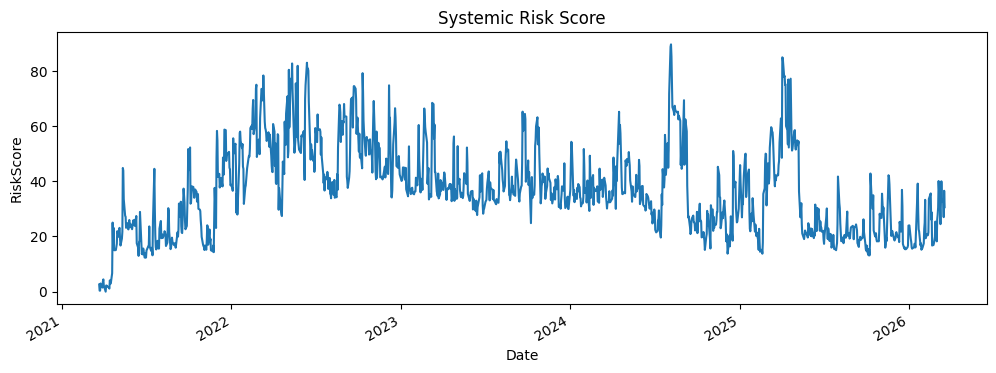

In [8]:
ax = risk.set_index("Date")["RiskScore"].plot(figsize=(12, 4), title="Systemic Risk Score")
ax.set_ylabel("RiskScore")